# From Spatial Frequencies to MRI Reconstruction

**DELTA DIY MRI Workshop — Reconstruction Team**

## Milestone

By the end of this notebook, you will understand how spatial information is represented using spatial frequencies, how a 2D object can be reduced to 1D projections, and how an MRI spin-echo experiment acquires the information needed to reconstruct 1D and 2D images.

We will follow two connected pathways.

### Part 1 — Start with an object

$$
\boxed{
\text{Spatial object}
\rightarrow
\text{spatial frequencies}
\rightarrow
\text{Fourier representation}
}
$$

### Part 2 — Start with an MRI measurement

$$
\boxed{
\text{Spin echo}
\rightarrow
\text{spatial encoding}
\rightarrow
\text{k-space}
\rightarrow
\text{reconstruction}
}
$$

The central idea of this notebook is:

> **MRI scanners do not directly measure images. They acquire signals containing spatial-frequency information, from which images are reconstructed.**

## Learning objectives

After completing this notebook, you should be able to:

- describe the relationship between a spatial object and its Fourier representation;
- explain what spatial frequency means;
- distinguish a 1D profile from a 1D projection;
- explain how a 2D object can produce 1D projections;
- recognize 2D k-space as the spatial-frequency representation of a 2D object;
- explain why an RF spin echo alone does not contain spatial information;
- explain how a readout gradient provides spatial encoding along one direction;
- reconstruct a 1D projection from a frequency-encoded readout;
- explain how phase encoding provides spatial information along a second direction;
- reconstruct a 2D image from Cartesian k-space.

# Where do we fit?

Acquisition Team is already working on MRI experiments to generate and receive MR signals.

The Reconstruction Team starts from those measurements and asks:

> **How do we recover spatial information from the acquired signal?**

Conceptually, the complete MRI workflow looks like this:

```text
            MRI EXPERIMENT

             Main magnet
                  ↓
            RF excitation
                  ↓
          Gradient encoding
                  ↓
         Signal acquisition
                  ↓
              Raw data
                  ↓
        ┌──────────────────┐
        │  RECONSTRUCTION  │   ← We are here
        └──────────────────┘
                  ↓
                Image


---

# Section 1 — How Spatial Objects Become Spatial Frequencies

# 1. How Spatial Objects Become Spatial Frequencies

Before discussing MRI reconstruction, we need to understand one fundamental relationship:

$$
\boxed{
\text{spatial information}
\;\xleftrightarrow{\mathrm{Fourier}}\;
\text{spatial-frequency information}
}
$$

We will begin with a simple 1D object.

Then we will extend the same idea to a 2D numerical phantom.

## 1.1 A simple 1D spatial object

Consider an object that varies along only one spatial direction, $x$.

We describe it using:

$$
\rho(x),
$$

where:

- $x$ represents spatial position;
- $\rho(x)$ represents signal intensity.

Let's create a simple rectangular object.

Number of samples: 256
Field of view: 200 mm
Spatial sampling interval: 0.781 mm


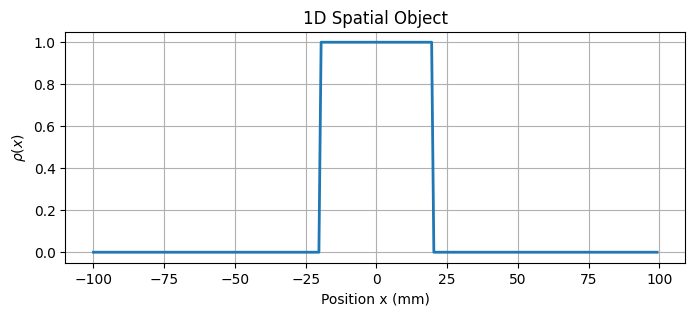

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Number of spatial samples
N = 256

# Field of view
FOV = 200  # mm

# Spatial sampling interval
dx = FOV / N

# Spatial coordinates centered around x = 0
x = (np.arange(N) - N / 2) * dx

print(f"Number of samples: {N}")
print(f"Field of view: {FOV} mm")
print(f"Spatial sampling interval: {dx:.3f} mm")

# Start with an empty object
rho_1d = np.zeros(N)

# Width of the rectangular object
object_width = 40  # mm

# Assign signal inside the rectangle
rho_1d[np.abs(x) <= object_width / 2] = 1.0

# Display
plt.figure(figsize=(8, 3))

plt.plot(x, rho_1d, linewidth=2)

plt.xlabel("Position x (mm)")
plt.ylabel(r"$\rho(x)$")
plt.title("1D Spatial Object")
plt.grid(True)

plt.show()

This is the **spatial domain**.

Looking at $\rho(x)$, we can directly identify:

- where the object is located;
- its width;
- its signal intensity;
- its boundaries.

But there is another way to describe exactly the same object.

Instead of asking:

> Where is the signal?

we can ask:

> How rapidly does the signal change across space?

That brings us to **spatial frequency**.

## 1.2 What is spatial frequency?

Imagine spatial patterns such as:

```text
A:  ███████████████

B:  ███    ███

C:  █ █ █ █ █ █ █



## 1.3 Fourier representation of the 1D object

The Fourier transform converts the spatial object $\rho(x)$ into its spatial-frequency representation:

$$
S(k_x)
=
\int
\rho(x)e^{-i2\pi k_xx}\,dx.
$$

Therefore:

$$
\boxed{
\rho(x)
\xrightarrow{\mathrm{Fourier\ transform}}
S(k_x)
}
$$

Let's calculate it.

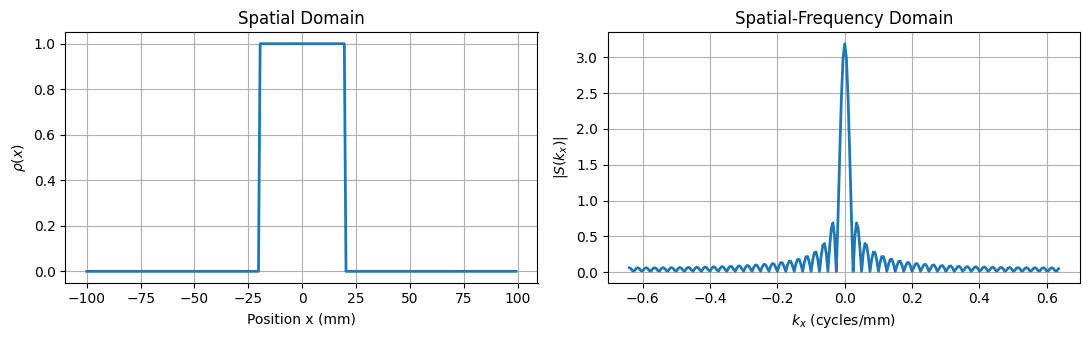

In [75]:
# Fourier transform of the 1D object
S_kx = np.fft.fftshift(
    np.fft.fft(
        np.fft.ifftshift(rho_1d),
        norm="ortho"
    )
)

# Corresponding spatial-frequency coordinates
kx = np.fft.fftshift(
    np.fft.fftfreq(N, d=dx)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Spatial domain
axes[0].plot(x, rho_1d, linewidth=2)
axes[0].set_xlabel("Position x (mm)")
axes[0].set_ylabel(r"$\rho(x)$")
axes[0].set_title("Spatial Domain")
axes[0].grid(True)

# Spatial-frequency domain
axes[1].plot(kx, np.abs(S_kx), linewidth=2)
axes[1].set_xlabel(r"$k_x$ (cycles/mm)")
axes[1].set_ylabel(r"$|S(k_x)|$")
axes[1].set_title("Spatial-Frequency Domain")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The two plots describe the **same object**.

The left side tells us where the signal exists:

$$
\rho(x).
$$

The right side tells us which spatial frequencies are required to represent it:

$$
S(k_x).
$$

The center,

$$
k_x=0,
$$

represents the lowest spatial frequency.

As we move away from the center, $|k_x|$ increases and the spatial frequency becomes higher.

Our rectangular object contains sharp edges, so its Fourier representation extends over a broad range of spatial frequencies.

## 1.4 The Fourier data are complex

The Fourier representation is generally complex:

$$
S(k_x)
=
\operatorname{Re}\{S(k_x)\}
+
i\operatorname{Im}\{S(k_x)\}.
$$

Let's inspect its real and imaginary components.

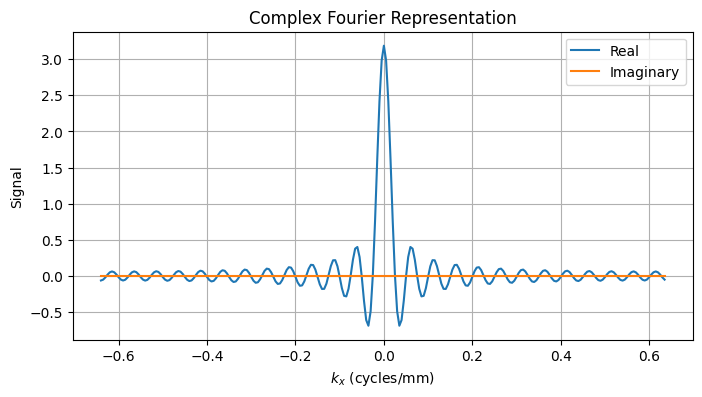

In [55]:
plt.figure(figsize=(8, 4))

plt.plot(
    kx,
    np.real(S_kx),
    label="Real"
)

plt.plot(
    kx,
    np.imag(S_kx),
    label="Imaginary"
)

plt.xlabel(r"$k_x$ (cycles/mm)")
plt.ylabel("Signal")
plt.title("Complex Fourier Representation")
plt.legend()
plt.grid(True)

plt.show()

For this particular object, the imaginary component is close to zero because the object is real, symmetric, and centered.

That is a special case.

In general, MRI k-space contains both real and imaginary components.

## 1.5 Return to spatial space

The Fourier relationship works in both directions.

If $S(k_x)$ is known, we can recover the spatial object using the inverse Fourier transform:

$$
S(k_x)
\xrightarrow{\mathrm{IFFT}}
\rho(x).
$$

Therefore:

$$
\boxed{
\rho(x)
\xrightarrow{\mathrm{FFT}}
S(k_x)
\xrightarrow{\mathrm{IFFT}}
\rho(x)
}
$$

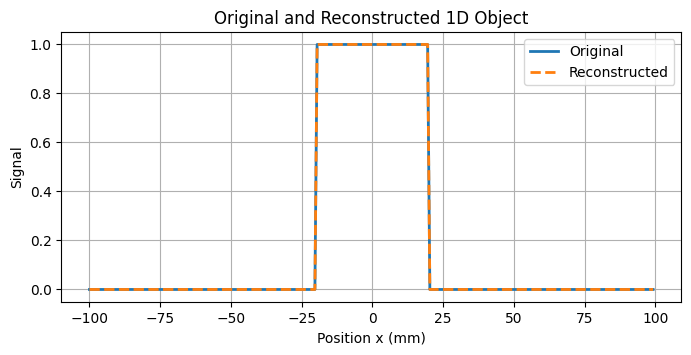

In [56]:
rho_1d_recon = np.fft.fftshift(
    np.fft.ifft(
        np.fft.ifftshift(S_kx),
        norm="ortho"
    )
)

plt.figure(figsize=(8, 3.5))

plt.plot(
    x,
    rho_1d,
    linewidth=2,
    label="Original"
)

plt.plot(
    x,
    np.abs(rho_1d_recon),
    "--",
    linewidth=2,
    label="Reconstructed"
)

plt.xlabel("Position x (mm)")
plt.ylabel("Signal")
plt.title("Original and Reconstructed 1D Object")
plt.legend()
plt.grid(True)

plt.show()

Our first important relationship is therefore:

$$
\boxed{
\rho(x)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x)
}
$$

Now let's extend this idea from one spatial dimension to two.

## 1.6 Create a 2D numerical phantom

Real images contain information along more than one spatial direction.

A 2D object can be represented as:

$$
\rho(x,y).
$$

We will create a deliberately simple numerical phantom containing:

- one large circular background region;
- two smaller ring-shaped foreground structures;
- both rings aligned along the same horizontal row.

The simple geometry will make the $x$ and $y$ directions easy to understand.

Matrix size: 256 x 256
Field of view: 200 x 200 mm
Pixel size: 0.781 x 0.781 mm


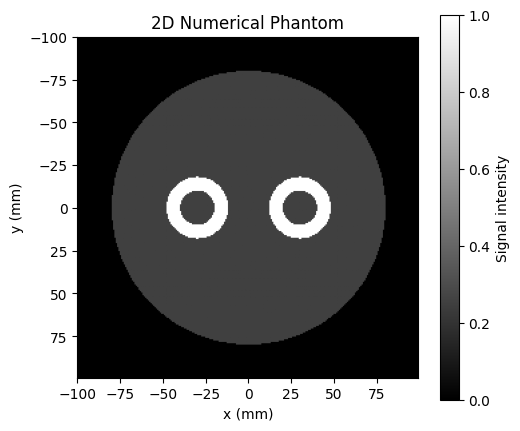

In [57]:
# Matrix size
N2 = 256

# Field of view
FOV2 = 200  # mm

# Spatial sampling intervals
dx2 = FOV2 / N2
dy2 = FOV2 / N2

# Spatial coordinates
x2 = (np.arange(N2) - N2 / 2) * dx2
y2 = (np.arange(N2) - N2 / 2) * dy2

# 2D coordinate grid
X, Y = np.meshgrid(x2, y2)

print(f"Matrix size: {N2} x {N2}")
print(f"Field of view: {FOV2} x {FOV2} mm")
print(f"Pixel size: {dx2:.3f} x {dy2:.3f} mm")

# Start with an empty image
phantom = np.zeros((N2, N2))

# --------------------------------------------------
# Large circular background
# --------------------------------------------------

background_radius = 80  # mm

R_background = np.sqrt(X**2 + Y**2)

background_mask = (
    R_background <= background_radius
)

phantom[background_mask] = 0.25


# --------------------------------------------------
# Two foreground rings
# --------------------------------------------------

ring_inner_radius = 10  # mm
ring_outer_radius = 18  # mm

# Ring centers
x_left = -30
x_right = 30
y_ring = 0

# Distance from left-ring center
R_left = np.sqrt(
    (X - x_left)**2 +
    (Y - y_ring)**2
)

# Distance from right-ring center
R_right = np.sqrt(
    (X - x_right)**2 +
    (Y - y_ring)**2
)

# Ring masks
left_ring = (
    (R_left >= ring_inner_radius) &
    (R_left <= ring_outer_radius)
)

right_ring = (
    (R_right >= ring_inner_radius) &
    (R_right <= ring_outer_radius)
)

# Foreground signal
phantom[left_ring] = 1.0
phantom[right_ring] = 1.0

plt.figure(figsize=(5.5, 5))

plt.imshow(
    phantom,
    extent=[
        x2[0],
        x2[-1],
        y2[-1],
        y2[0]
    ],
    cmap="gray"
)

plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("2D Numerical Phantom")

plt.colorbar(
    label="Signal intensity"
)

plt.show()

Our object is now described by:

$$
\rho(x,y).
$$

Unlike the 1D example, spatial information exists independently along both $x$ and $y$.

## 1.7 Look through the phantom along $x$ and $y$

Before calculating projections, let's simply take **profiles** through the phantom.

A profile is a line through a selected location in the image.

Because both rings are centered along:

$$
y=0,
$$

a horizontal profile through $y=0$ passes through both structures.

We can also take vertical profiles through the center of each ring.

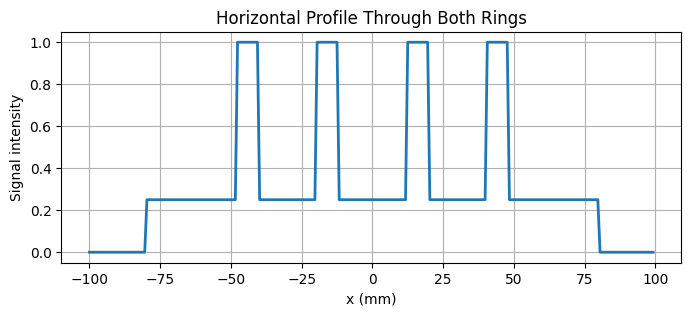

In [58]:
# Index closest to y = 0
iy_center = np.argmin(
    np.abs(y2 - 0)
)

# Indices through the two ring centers
ix_left = np.argmin(
    np.abs(x2 - x_left)
)

ix_right = np.argmin(
    np.abs(x2 - x_right)
)

# Horizontal profile through both rings
profile_x = phantom[
    iy_center,
    :
]

# Vertical profiles
profile_y_left = phantom[
    :,
    ix_left
]

profile_y_right = phantom[
    :,
    ix_right
]

plt.figure(figsize=(8, 3))

plt.plot(
    x2,
    profile_x,
    linewidth=2
)

plt.xlabel("x (mm)")
plt.ylabel("Signal intensity")
plt.title("Horizontal Profile Through Both Rings")
plt.grid(True)

plt.show()

Along $x$, the two rings appear at different spatial locations because they are separated horizontally.

Now let's look vertically through each ring.

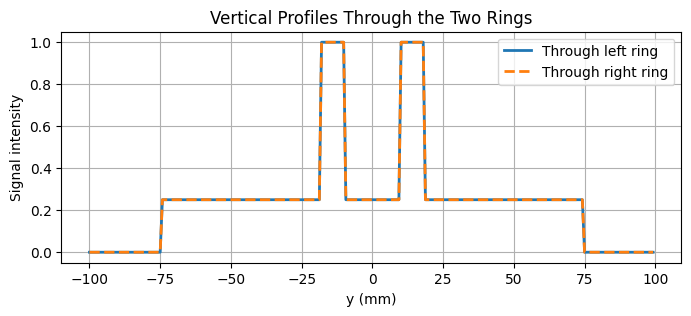

In [59]:
plt.figure(figsize=(8, 3))

plt.plot(
    y2,
    profile_y_left,
    linewidth=2,
    label="Through left ring"
)

plt.plot(
    y2,
    profile_y_right,
    "--",
    linewidth=2,
    label="Through right ring"
)

plt.xlabel("y (mm)")
plt.ylabel("Signal intensity")
plt.title("Vertical Profiles Through the Two Rings")
plt.legend()
plt.grid(True)

plt.show()

The two vertical profiles nearly overlap.

Why?

Because the two foreground structures:

- have the same size;
- have the same intensity;
- occupy the same $y$ position.

They differ only in their $x$ positions.

These are **profiles** through selected locations.

A projection is different.

## 1.8 From a 2D object to a 1D projection

A **profile** examines one line through an object.

A **projection** combines signal from the entire object along one direction.

Consider the projection onto the $x$-axis.

At every $x$ position, we add together all signal values along $y$:

$$
P_x(x)
=
\int
\rho(x,y)
\,dy.
$$

Conceptually:

```text
              2D object

             ○        ○
         ┌─────────────────┐
         │                 │
         │                 │
         └─────────────────┘

                  ↓
          collapse along y

                  ↓

                Pₓ(x)

           ___/\____/\___

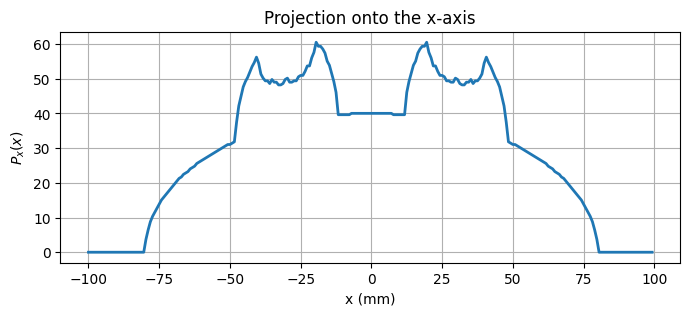

In [60]:

# Projection onto x:
# collapse the y dimension
projection_x = (
    np.sum(
        phantom,
        axis=0
    )
    * dy2
)

# Projection onto y:
# collapse the x dimension
projection_y = (
    np.sum(
        phantom,
        axis=1
    )
    * dx2
)

plt.figure(figsize=(8, 3))

plt.plot(
    x2,
    projection_x,
    linewidth=2
)

plt.xlabel("x (mm)")
plt.ylabel(r"$P_x(x)$")
plt.title("Projection onto the x-axis")
plt.grid(True)

plt.show()

Because the rings are separated along $x$, their contributions can be distinguished in $P_x(x)$.

Now look at the projection onto $y$.

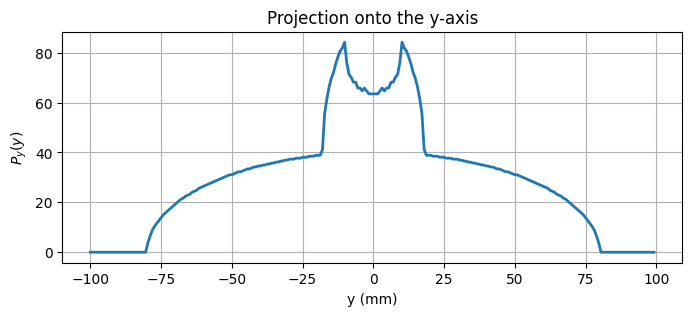

In [61]:
plt.figure(figsize=(8, 3))

plt.plot(
    y2,
    projection_y,
    linewidth=2
)

plt.xlabel("y (mm)")
plt.ylabel(r"$P_y(y)$")
plt.title("Projection onto the y-axis")
plt.grid(True)

plt.show()

Because both rings occupy the same $y$ position, their contributions overlap in $P_y(y)$.

This demonstrates what is lost when one spatial dimension is collapsed.

## 1.9 See the object and projections together

The following figure shows the relationship between the 2D object and its two 1D projections.

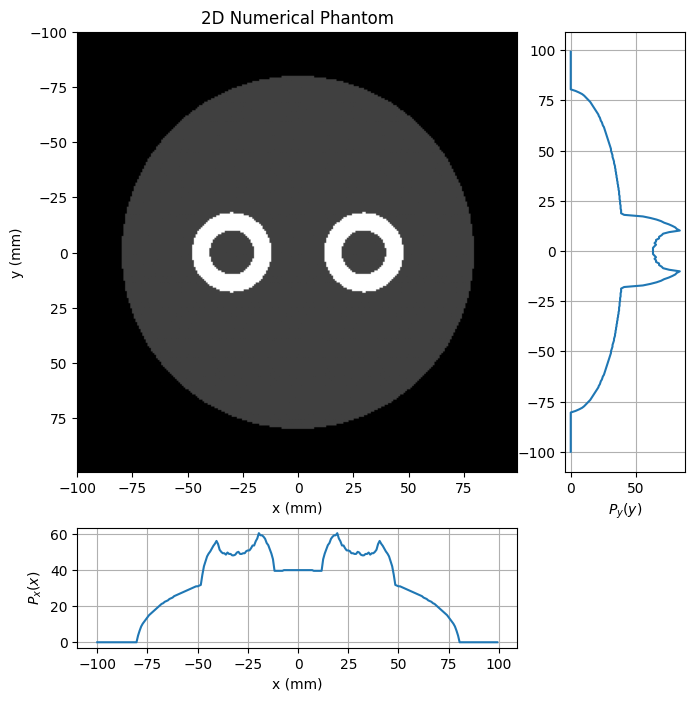

In [62]:
fig = plt.figure(
    figsize=(8, 8)
)

# --------------------------------
# Main phantom
# --------------------------------

ax_main = fig.add_axes(
    [0.12, 0.30, 0.55, 0.55]
)

ax_main.imshow(
    phantom,
    extent=[
        x2[0],
        x2[-1],
        y2[-1],
        y2[0]
    ],
    cmap="gray"
)

ax_main.set_xlabel("x (mm)")
ax_main.set_ylabel("y (mm)")
ax_main.set_title(
    "2D Numerical Phantom"
)


# --------------------------------
# Projection onto x
# --------------------------------

ax_x = fig.add_axes(
    [0.12, 0.08, 0.55, 0.15]
)

ax_x.plot(
    x2,
    projection_x
)

ax_x.set_xlabel("x (mm)")
ax_x.set_ylabel(r"$P_x(x)$")
ax_x.grid(True)


# --------------------------------
# Projection onto y
# --------------------------------

ax_y = fig.add_axes(
    [0.73, 0.30, 0.15, 0.55]
)

ax_y.plot(
    projection_y,
    y2
)

ax_y.set_xlabel(r"$P_y(y)$")
ax_y.set_ylabel("y (mm)")
ax_y.grid(True)

plt.show()

This is one of the most important ideas in today's notebook.

The complete object is:

$$
\rho(x,y).
$$

A projection contains only one spatial dimension:

$$
P_x(x)
$$

or:

$$
P_y(y).
$$

Later, we will see that a single frequency-encoded MRI readout can recover exactly this kind of **1D projection**.

To recover the complete 2D object, MRI must encode a second spatial dimension.

Keep this idea in mind.

## 1.10 From a 2D object to spatial frequencies

We already learned that:

$$
\rho(x)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x).
$$

Our phantom contains spatial information along two dimensions:

$$
\rho(x,y).
$$

Therefore its Fourier representation must also contain two spatial-frequency coordinates:

$$
k_x
\quad\text{and}\quad
k_y.
$$

The two-dimensional Fourier transform is:

$$
S(k_x,k_y)
=
\iint
\rho(x,y)
e^{-i2\pi(k_xx+k_yy)}
\,dx\,dy.
$$

Therefore:

$$
\boxed{
\rho(x,y)
\xrightarrow{\mathrm{2D\ Fourier\ transform}}
S(k_x,k_y)
}
$$

In MRI, we call this 2D spatial-frequency representation **k-space**.

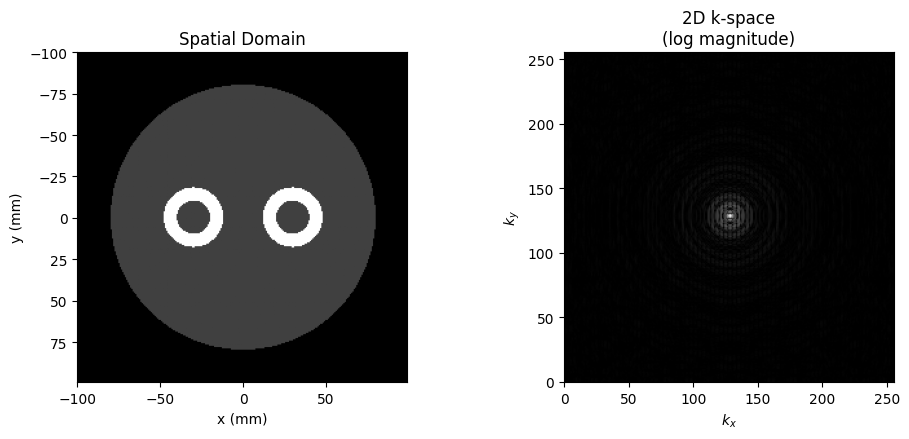

In [63]:
kspace_2d = np.fft.fftshift(
    np.fft.fft2(
        np.fft.ifftshift(phantom),
        norm="ortho"
    )
)

# Log magnitude makes the large dynamic range
# easier to visualize
kspace_display = np.log1p(
    np.abs(kspace_2d)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5)
)

# Spatial object
axes[0].imshow(
    phantom,
    cmap="gray",
    extent=[
        x2[0],
        x2[-1],
        y2[-1],
        y2[0]
    ]
)

axes[0].set_title(
    "Spatial Domain"
)

axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")


# k-space
axes[1].imshow(
    kspace_display,
    cmap="gray",
    origin="lower"
)

axes[1].set_title(
    "2D k-space\n(log magnitude)"
)

axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")

plt.tight_layout()
plt.show()

The two images again describe the **same object**.

On the left:

$$
\rho(x,y)
$$

describes where signal is located.

On the right:

$$
S(k_x,k_y)
$$

describes the spatial frequencies contained in that object.

Each point in k-space corresponds to a particular combination:

$$
(k_x,k_y).
$$

The center:

$$
(k_x,k_y)=(0,0)
$$

corresponds to the lowest spatial frequencies.

Moving farther away from the center corresponds to higher spatial frequencies.

For now, the key relationship is simply:

$$
\boxed{
\rho(x,y)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x,k_y)
}
$$

## 1.11 Reconstruct the 2D object

The Fourier relationship works in both directions.

If we know the complete 2D k-space:

$$
S(k_x,k_y),
$$

we can reconstruct the spatial object using a 2D inverse Fourier transform:

$$
S(k_x,k_y)
\xrightarrow{\mathrm{IFFT2}}
\rho(x,y).
$$

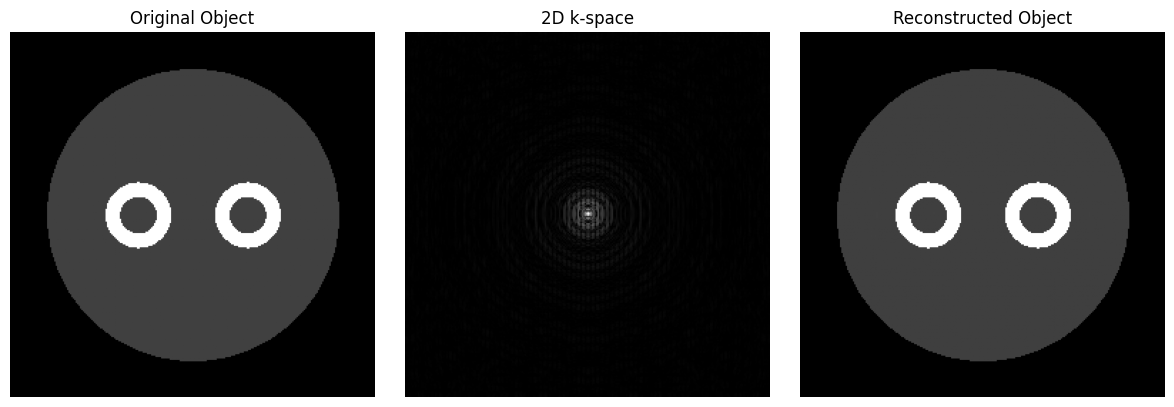

In [64]:
phantom_recon = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(kspace_2d),
        norm="ortho"
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

# Original
axes[0].imshow(
    phantom,
    cmap="gray"
)

axes[0].set_title(
    "Original Object"
)

axes[0].axis("off")


# k-space
axes[1].imshow(
    np.log1p(
        np.abs(kspace_2d)
    ),
    cmap="gray",
    origin="lower"
)

axes[1].set_title(
    "2D k-space"
)

axes[1].axis("off")


# Reconstruction
axes[2].imshow(
    np.abs(phantom_recon),
    cmap="gray"
)

axes[2].set_title(
    "Reconstructed Object"
)

axes[2].axis("off")


plt.tight_layout()
plt.show()

# Checkpoint — What have we learned so far?

For a 1D object:

$$
\boxed{
\rho(x)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x)
}
$$

For a 2D object:

$$
\boxed{
\rho(x,y)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x,k_y)
}
$$

A 2D object can also be collapsed into a 1D projection:

$$
\boxed{
P_x(x)
=
\int
\rho(x,y)\,dy
}
$$

or:

$$
\boxed{
P_y(y)
=
\int
\rho(x,y)\,dx
}
$$

So far, however, we started from an object that we **already knew**.

We calculated its Fourier representation ourselves:

$$
\text{known object}
\rightarrow
S(k_x,k_y).
$$

MRI has the opposite problem.

# The MRI reconstruction problem

Inside the scanner, we do not know:

$$
\rho(x,y).
$$

That is what we are trying to measure.

Therefore MRI must somehow acquire the information that belongs in:

$$
S(k_x,k_y).
$$

The MRI problem is:

$$
\boxed{
\text{unknown object}
\rightarrow
\text{MRI measurement}
\rightarrow
S(k_x,k_y)
\rightarrow
\rho(x,y)
}
$$

So the next question is:

> **How does an MRI scanner acquire spatial-frequency information?**

We will build the answer progressively:

$$
\boxed{
\text{RF spin echo}
\rightarrow
\text{frequency encoding}
\rightarrow
\text{1D projection}
\rightarrow
\text{phase encoding}
\rightarrow
\text{2D k-space}
\rightarrow
\text{2D image}
}
$$

# 2. How MRI Acquires Spatial Frequencies

We will now connect the spatial-frequency concepts from Section 1 to the spin-echo experiment developed by the Acquisition Team.

At each stage, we will ask:

> **What does the scanner know now, and what can we reconstruct from it?**

## 2.1 Start with an RF spin echo

The Acquisition Team began with a basic spin-echo experiment.

A simplified sequence contains:

1. a $90^\circ$ excitation pulse;
2. a $180^\circ$ refocusing pulse;
3. formation of a spin echo at echo time $TE$;
4. ADC sampling of the received MR signal.

The echo time $TE$ is measured from the center of the $90^\circ$ excitation pulse to the center of the spin echo.

For an ideal spin echo, the $180^\circ$ pulse occurs halfway between excitation and the echo:

$$
t_{180}
=
t_{90}
+
\frac{TE}{2}.
$$

The echo therefore forms at:

$$
t_{\mathrm{echo}}
=
t_{90}
+
TE.
$$

Conceptually:

$$
90^\circ
\rightarrow
180^\circ
\rightarrow
\text{spin echo}.
$$

Let's first visualize the sequence.

90° pulse: 10 ms
180° pulse: 30 ms
Echo center: 50 ms
TE: 40 ms


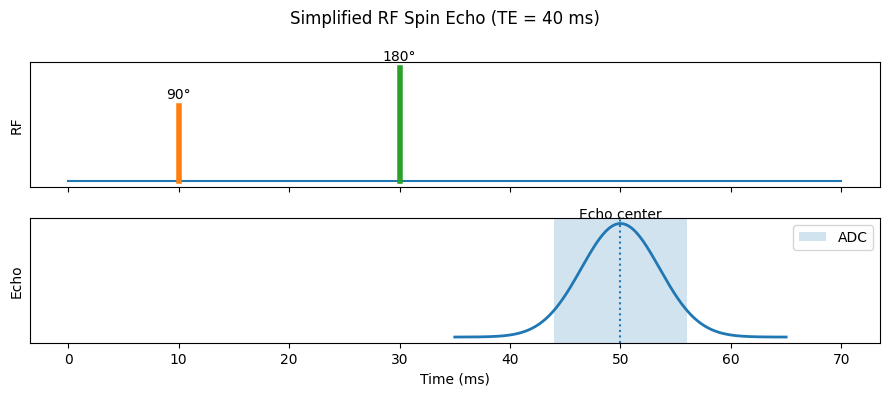

In [65]:
# --------------------------------------------------
# Spin-echo timing
# --------------------------------------------------

t90 = 10       # ms
TE = 40        # ms, measured from excitation to echo

t180 = t90 + TE / 2
t_echo_center = t90 + TE

print(f"90° pulse: {t90:.0f} ms")
print(f"180° pulse: {t180:.0f} ms")
print(f"Echo center: {t_echo_center:.0f} ms")
print(f"TE: {TE:.0f} ms")


# --------------------------------------------------
# Plot sequence
# --------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 4),
    sharex=True
)

# RF channel
axes[0].plot([0, 70], [0, 0])

axes[0].plot(
    [t90, t90],
    [0, 1],
    linewidth=4
)

axes[0].plot(
    [t180, t180],
    [0, 1.5],
    linewidth=4
)

axes[0].text(
    t90,
    1.1,
    "90°",
    ha="center"
)

axes[0].text(
    t180,
    1.6,
    "180°",
    ha="center"
)

axes[0].set_ylabel("RF")
axes[0].set_yticks([])


# Spin-echo envelope
t_echo = np.linspace(35, 65, 600)

echo_envelope = np.exp(
    -((t_echo - t_echo_center) / 5)**2
)

axes[1].plot(
    t_echo,
    echo_envelope,
    linewidth=2
)

axes[1].axvspan(
    44,
    56,
    alpha=0.2,
    label="ADC"
)

axes[1].axvline(
    t_echo_center,
    linestyle=":"
)

axes[1].text(
    t_echo_center,
    1.05,
    "Echo center",
    ha="center"
)

axes[1].set_ylabel("Echo")
axes[1].set_xlabel("Time (ms)")
axes[1].set_yticks([])
axes[1].legend()

plt.suptitle(
    f"Simplified RF Spin Echo (TE = {TE:.0f} ms)"
)

plt.tight_layout()
plt.show()

## 2.2 What does the received MR signal look like?

The previous figure showed the **spin-echo envelope**.

However, the actual received MR signal is complex and oscillatory.

An MR receiver measures:

$$
S(t)
=
I(t)
+
iQ(t).
$$

A simple way to visualize this is as an oscillating complex signal contained within the spin-echo envelope.

The following example is intended to illustrate the form of the received signal rather than simulate the complete spin physics.

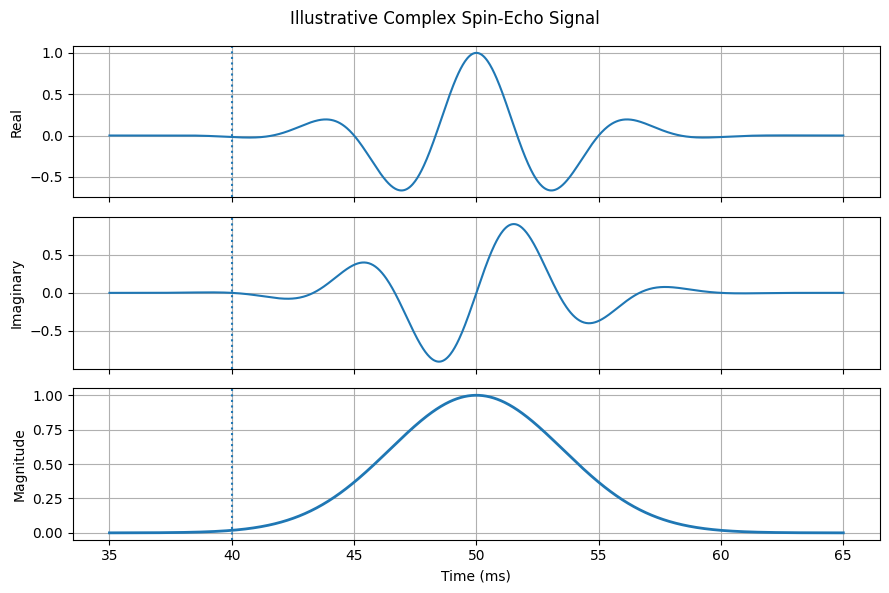

In [67]:
# Time axis around the spin echo
t_signal = np.linspace(
    35,
    65,
    1000
)

# Time relative to the echo center
t_relative = (
    t_signal - t_echo_center
) / 1000  # seconds

# Spin-echo envelope
echo_width = 5.0  # ms

envelope = np.exp(
    -(
        (t_signal - t_echo_center)
        / echo_width
    )**2
)

# Illustrative receiver frequency
receiver_frequency = 150  # Hz

# Complex received MR signal
spin_echo_signal = (
    envelope
    *
    np.exp(
        1j
        * 2
        * np.pi
        * receiver_frequency
        * t_relative
    )
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 6),
    sharex=True
)

# Real component
axes[0].plot(
    t_signal,
    np.real(spin_echo_signal)
)

axes[0].set_ylabel("Real")


# Imaginary component
axes[1].plot(
    t_signal,
    np.imag(spin_echo_signal)
)

axes[1].set_ylabel("Imaginary")


# Magnitude
axes[2].plot(
    t_signal,
    np.abs(spin_echo_signal),
    linewidth=2
)

axes[2].set_ylabel("Magnitude")
axes[2].set_xlabel("Time (ms)")


# Mark TE
for ax in axes:

    ax.axvline(
        TE,
        linestyle=":"
    )

    ax.grid(True)


plt.suptitle(
    "Illustrative Complex Spin-Echo Signal"
)

plt.tight_layout()
plt.show()

Now we are looking at something closer to the type of complex signal received by the scanner.

The ADC samples:

$$
S(t).
$$

But there is still a problem.

We have not applied any spatial encoding.

The signal contains contributions from the excited object, but we do not yet know **where those contributions originated**.

Therefore:

$$
\boxed{
\text{RF spin echo}
\rightarrow
S(t)
\rightarrow
\text{no spatial information}
}
$$

To reconstruct spatial information, we need gradients.

## 2.3 Add a gradient along $x$

Suppose we want to encode position along:

$$
x.
$$

We apply a magnetic-field gradient:

$$
G_x.
$$

During the gradient, the magnetic field varies with position:

$$
B(x)
=
B_0
+
G_xx.
$$

The corresponding precession frequency becomes:

$$
f(x)
=
f_0
+
\frac{\gamma}{2\pi}G_xx.
$$

Therefore spins at different $x$ positions precess at different frequencies.

Conceptually:

$$
\boxed{
x
\longrightarrow
\text{frequency}
}
$$

This is called **frequency encoding**.

## 2.4 Frequency-encoded spin echo

To acquire a complete frequency-encoded readout, we add:

- a readout prephasing gradient;
- a positive readout gradient $G_x$;
- ADC sampling during the readout.

The prephasing gradient first moves the acquisition toward negative $k_x$.

The positive readout gradient then traverses the required range of spatial frequencies while the ADC records the MR signal.

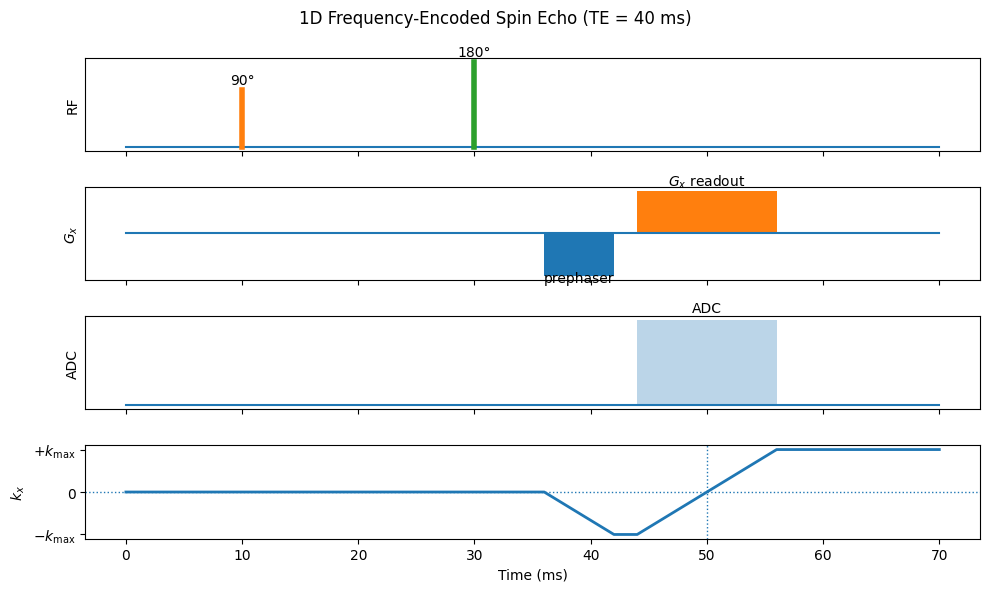

In [68]:
# --------------------------------------------------
# 1D frequency-encoded spin-echo acquisition
# --------------------------------------------------

fig, axes = plt.subplots(
    4,
    1,
    figsize=(10, 6),
    sharex=True
)

# --------------------------------
# RF
# --------------------------------

axes[0].plot(
    [0, 70],
    [0, 0]
)

axes[0].plot(
    [t90, t90],
    [0, 1],
    linewidth=4
)

axes[0].plot(
    [t180, t180],
    [0, 1.5],
    linewidth=4
)

axes[0].text(
    t90,
    1.1,
    "90°",
    ha="center"
)

axes[0].text(
    t180,
    1.6,
    "180°",
    ha="center"
)

axes[0].set_ylabel("RF")
axes[0].set_yticks([])


# --------------------------------
# Gx
# --------------------------------

axes[1].plot(
    [0, 70],
    [0, 0]
)

# Readout prephaser
# Area = (-1.0) x 6 ms = -6
axes[1].fill_between(
    [36, 42],
    [0, 0],
    [-1.0, -1.0]
)

axes[1].text(
    39,
    -1.15,
    "prephaser",
    ha="center"
)

# Positive readout gradient
# Area = (+1.0) x 12 ms = +12
axes[1].fill_between(
    [44, 56],
    [0, 0],
    [1.0, 1.0]
)

axes[1].text(
    50,
    1.12,
    r"$G_x$ readout",
    ha="center"
)

axes[1].set_ylabel(r"$G_x$")
axes[1].set_yticks([])


# --------------------------------
# ADC
# --------------------------------

axes[2].plot(
    [0, 70],
    [0, 0]
)

axes[2].fill_between(
    [44, 56],
    [0, 0],
    [1, 1],
    alpha=0.3
)

axes[2].text(
    50,
    1.1,
    "ADC",
    ha="center"
)

axes[2].set_ylabel("ADC")
axes[2].set_yticks([])


# --------------------------------
# kx trajectory
# --------------------------------

# The -6 prephaser area moves the trajectory
# from kx = 0 to -kmax.
#
# The +12 readout area then traverses:
# -kmax -> 0 -> +kmax.
#
# kx = 0 occurs at the center of the readout,
# which coincides with the spin-echo center.

axes[3].plot(
    [0, 36, 42, 44, 50, 56, 70],
    [0, 0, -1, -1, 0, 1, 1],
    linewidth=2
)

axes[3].axhline(
    0,
    linestyle=":",
    linewidth=1
)

axes[3].axvline(
    t_echo_center,
    linestyle=":",
    linewidth=1
)

axes[3].set_ylabel(r"$k_x$")
axes[3].set_xlabel("Time (ms)")

axes[3].set_yticks(
    [-1, 0, 1]
)

axes[3].set_yticklabels(
    [
        r"$-k_{\max}$",
        "0",
        r"$+k_{\max}$"
    ]
)

plt.suptitle(
    f"1D Frequency-Encoded Spin Echo (TE = {TE:.0f} ms)"
)

plt.tight_layout()
plt.show()

The gradient determines our location in spatial-frequency space.

The $k_x$ coordinate is:

$$
k_x(t)
=
\frac{\gamma}{2\pi}
\int_0^t
G_x(\tau)\,d\tau.
$$

The prephasing gradient moves us toward negative $k_x$.

During the readout gradient, the acquisition moves approximately from:

$$
-k_{x,\max}
\rightarrow
0
\rightarrow
+k_{x,\max}.
$$

The ADC still samples data over time:

$$
S(t).
$$

But because the gradient trajectory is known, each time sample corresponds to a known $k_x$ location.

Therefore:

$$
\boxed{
S(t)
\rightarrow
S(k_x)
}
$$

We now have spatial-frequency information along one direction.

## 2.5 What can one frequency-encoded readout reconstruct?

This is where Section 1 becomes useful.

Earlier, we calculated a projection of our 2D object:

$$
P_x(x)
=
\int
\rho(x,y)
\,dy.
$$

We also learned the Fourier relationship:

$$
P_x(x)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x).
$$

Therefore:

$$
\boxed{
S(k_x)
\xrightarrow{\mathrm{IFFT}}
P_x(x)
}
$$

A single frequency-encoded readout does **not** reconstruct the complete 2D object.

It reconstructs a **1D projection**.

Let's demonstrate this using the same numerical phantom.

## 2.6 Simulate one frequency-encoded readout

The central $k_y=0$ line of our 2D Fourier representation contains the information corresponding to the $x$-projection.

We will use this line as a conceptual stand-in for a frequency-encoded MRI measurement.

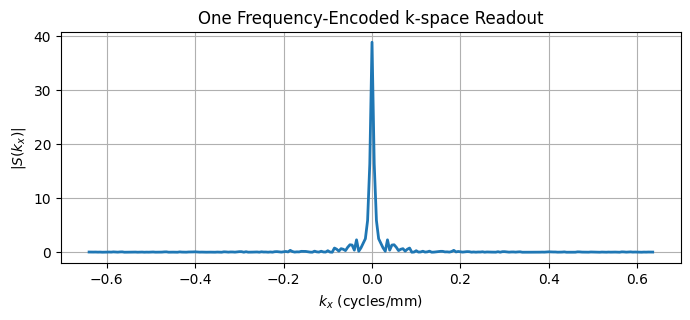

In [69]:
# Index corresponding to ky = 0
ky_center = N2 // 2

# One frequency-encoded k-space readout
S_kx_readout = kspace_2d[
    ky_center,
    :
]

# Spatial-frequency coordinate
kx2 = np.fft.fftshift(
    np.fft.fftfreq(
        N2,
        d=dx2
    )
)

plt.figure(figsize=(8, 3))

plt.plot(
    kx2,
    np.abs(S_kx_readout),
    linewidth=2
)

plt.xlabel(
    r"$k_x$ (cycles/mm)"
)

plt.ylabel(
    r"$|S(k_x)|$"
)

plt.title(
    "One Frequency-Encoded k-space Readout"
)

plt.grid(True)

plt.show()

This is now a one-dimensional set of spatial-frequency measurements:

$$
S(k_x).
$$

According to what we learned earlier, applying a 1D inverse Fourier transform should recover a spatial projection.

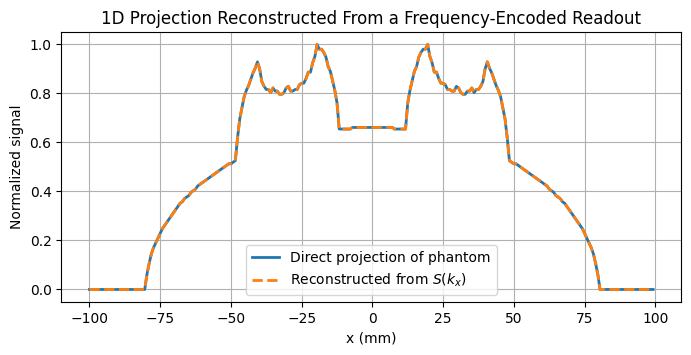

In [70]:
projection_mri = np.fft.fftshift(
    np.fft.ifft(
        np.fft.ifftshift(
            S_kx_readout
        ),
        norm="ortho"
    )
)

# Normalize both signals for visual comparison
projection_direct_display = (
    projection_x
    /
    np.max(projection_x)
)

projection_mri_display = (
    np.abs(projection_mri)
    /
    np.max(
        np.abs(projection_mri)
    )
)

plt.figure(figsize=(8, 3.5))

plt.plot(
    x2,
    projection_direct_display,
    linewidth=2,
    label="Direct projection of phantom"
)

plt.plot(
    x2,
    projection_mri_display,
    "--",
    linewidth=2,
    label="Reconstructed from $S(k_x)$"
)

plt.xlabel("x (mm)")
plt.ylabel("Normalized signal")

plt.title(
    "1D Projection Reconstructed From a Frequency-Encoded Readout"
)

plt.legend()
plt.grid(True)

plt.show()

This is the central conceptual bridge of the notebook.

Earlier:

$$
\rho(x,y)
\rightarrow
P_x(x).
$$

Now:

$$
S(k_x)
\rightarrow
P_x(x).
$$

And the results match.

Therefore:

$$
\boxed{
\text{one frequency-encoded readout}
\rightarrow
S(k_x)
\rightarrow
\text{one 1D projection}
}
$$

But our original object was two-dimensional.

A projection tells us how signal is distributed along $x$, but it has collapsed all information along $y$.

So we still cannot recover:

$$
\rho(x,y).
$$

We need one more spatial-encoding dimension.

## 2.7 Add phase encoding

Our readout gradient $G_x$ provides information along:

$$
k_x.
$$

To reconstruct a 2D object, we also need information along:

$$
k_y.
$$

MRI achieves this using another gradient:

$$
G_y.
$$

This is the **phase-encoding gradient**.

For one repetition of the sequence, a particular phase-encoding gradient amplitude determines one $k_y$ position.

The subsequent frequency-encoded readout acquires:

$$
S(k_x,k_{y,1}).
$$

The experiment is repeated with another $G_y$ amplitude:

$$
S(k_x,k_{y,2}).
$$

Then again:

$$
S(k_x,k_{y,3}).
$$

And so on.

Conceptually:

$$
\boxed{
\text{different phase encodes}
\rightarrow
\text{different }k_y\text{ positions}
}
$$

## 2.8 The 2D spin-echo imaging sequence

Let's extend the frequency-encoded spin-echo sequence by adding the phase-encoding gradient $G_y$.

The diagram below represents one phase-encoding step.

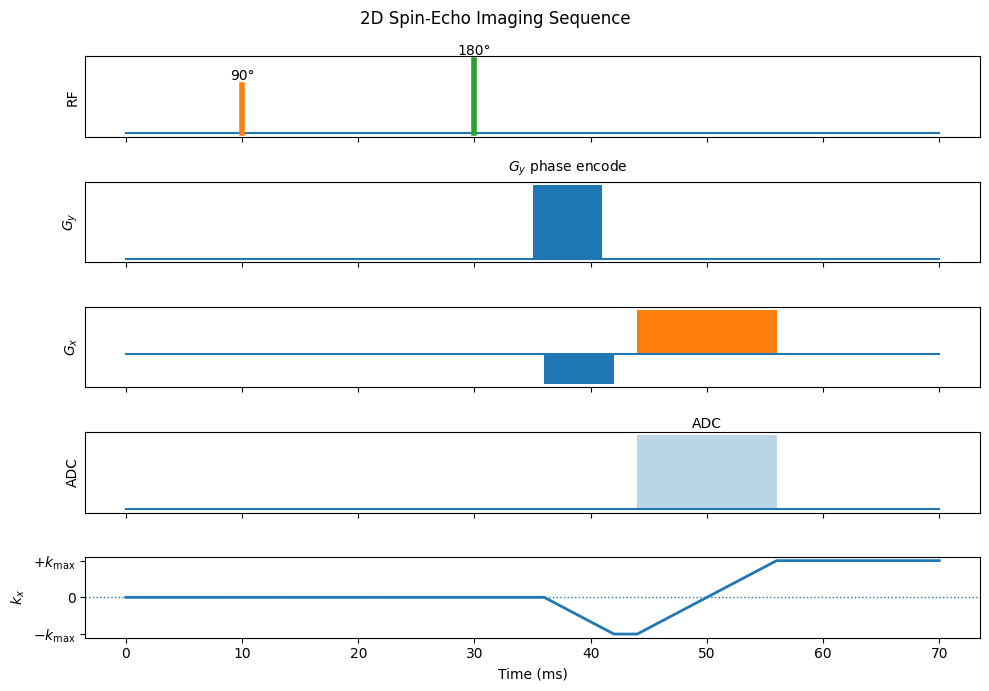

In [71]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(10, 7),
    sharex=True
)

# --------------------------------
# RF
# --------------------------------

axes[0].plot(
    [0, 70],
    [0, 0]
)

axes[0].plot(
    [10, 10],
    [0, 1],
    linewidth=4
)

axes[0].plot(
    [30, 30],
    [0, 1.5],
    linewidth=4
)

axes[0].text(
    10,
    1.1,
    "90°",
    ha="center"
)

axes[0].text(
    30,
    1.6,
    "180°",
    ha="center"
)

axes[0].set_ylabel("RF")
axes[0].set_yticks([])


# --------------------------------
# Gy phase encoding
# --------------------------------

axes[1].plot(
    [0, 70],
    [0, 0]
)

axes[1].fill_between(
    [35, 41],
    [0, 0],
    [0.8, 0.8]
)

axes[1].text(
    38,
    0.95,
    r"$G_y$ phase encode",
    ha="center"
)

axes[1].set_ylabel(r"$G_y$")
axes[1].set_yticks([])


# --------------------------------
# Gx readout
# --------------------------------

axes[2].plot(
    [0, 70],
    [0, 0]
)

# Prephaser
axes[2].fill_between(
    [36, 42],
    [0, 0],
    [-0.7, -0.7]
)

# Readout
axes[2].fill_between(
    [44, 56],
    [0, 0],
    [1, 1]
)

axes[2].set_ylabel(r"$G_x$")
axes[2].set_yticks([])


# --------------------------------
# ADC
# --------------------------------

axes[3].plot(
    [0, 70],
    [0, 0]
)

axes[3].fill_between(
    [44, 56],
    [0, 0],
    [1, 1],
    alpha=0.3
)

axes[3].text(
    50,
    1.1,
    "ADC",
    ha="center"
)

axes[3].set_ylabel("ADC")
axes[3].set_yticks([])


# --------------------------------
# kx trajectory
# --------------------------------

axes[4].plot(
    [0, 36, 42, 44, 50, 56, 70],
    [0, 0, -1, -1, 0, 1, 1],
    linewidth=2
)

axes[4].axhline(
    0,
    linestyle=":",
    linewidth=1
)

axes[4].set_ylabel(r"$k_x$")
axes[4].set_xlabel("Time (ms)")

axes[4].set_yticks(
    [-1, 0, 1]
)

axes[4].set_yticklabels(
    [
        r"$-k_{\max}$",
        "0",
        r"$+k_{\max}$"
    ]
)

plt.suptitle(
    "2D Spin-Echo Imaging Sequence"
)

plt.tight_layout()
plt.show()

For this repetition:

1. $G_y$ determines the $k_y$ position;
2. the $G_x$ prephaser moves toward negative $k_x$;
3. the readout gradient traverses $k_x$;
4. ADC sampling acquires one complete k-space line.

Therefore:

$$
\boxed{
\text{one spin-echo repetition}
\rightarrow
\text{one }k_x\text{ line at one }k_y
}
$$

The sequence is repeated using different $G_y$ amplitudes:

$$
\boxed{
\text{many repetitions}
\rightarrow
\text{many }k_x\text{ lines}
\rightarrow
S(k_x,k_y)
}
$$

## 2.9 Frequency-encoded readouts at different $k_y$ positions

Each phase-encoding step produces a different frequency-encoded readout.

The readout direction remains $k_x$.

What changes from repetition to repetition is the $k_y$ position.

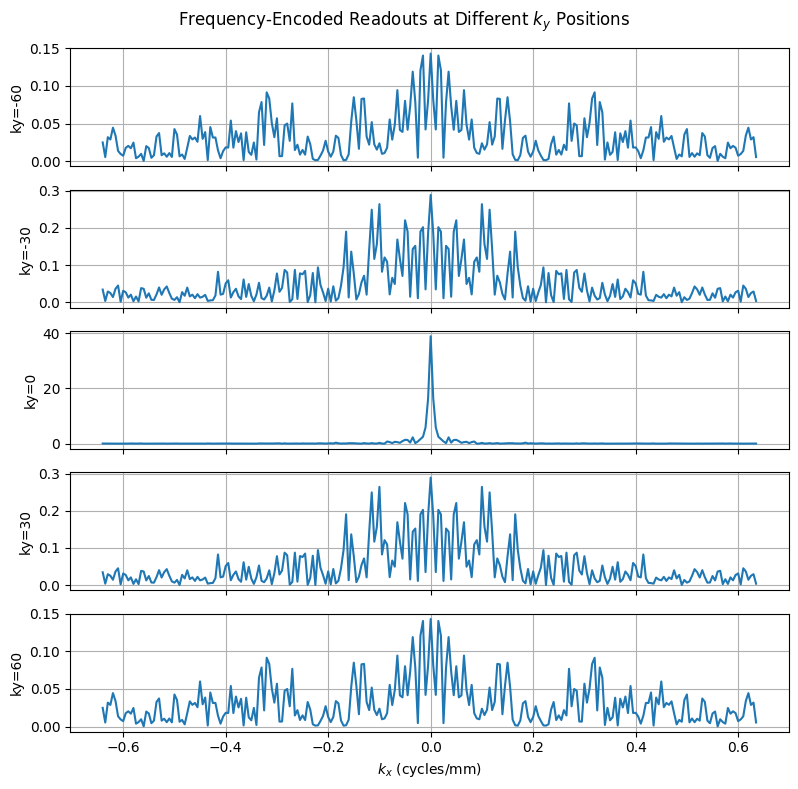

In [72]:
# Choose several ky positions
selected_ky = [
    N2 // 2 - 60,
    N2 // 2 - 30,
    N2 // 2,
    N2 // 2 + 30,
    N2 // 2 + 60
]

fig, axes = plt.subplots(
    len(selected_ky),
    1,
    figsize=(8, 8),
    sharex=True
)

for ax, ky_index in zip(
    axes,
    selected_ky
):

    ax.plot(
        kx2,
        np.abs(
            kspace_2d[
                ky_index,
                :
            ]
        )
    )

    ax.set_ylabel(
        f"ky={ky_index - N2//2}"
    )

    ax.grid(True)

axes[-1].set_xlabel(
    r"$k_x$ (cycles/mm)"
)

plt.suptitle(
    "Frequency-Encoded Readouts at Different $k_y$ Positions"
)

plt.tight_layout()
plt.show()

Each curve represents one frequency-encoded readout:

$$
S(k_x,k_{y,n}).
$$

The readout dimension is always:

$$
k_x.
$$

What changes between repetitions is:

$$
k_y.
$$

Together, these measurements form a two-dimensional k-space dataset.

## 2.10 Build 2D k-space line by line

We can now visualize how repeated phase-encoding steps build a 2D dataset.

Conceptually:

$$
\begin{array}{c}
S(k_x,k_{y,1})\\
S(k_x,k_{y,2})\\
S(k_x,k_{y,3})\\
\vdots\\
S(k_x,k_{y,N})
\end{array}
$$

Together these lines form:

$$
\boxed{
S(k_x,k_y)
}
$$

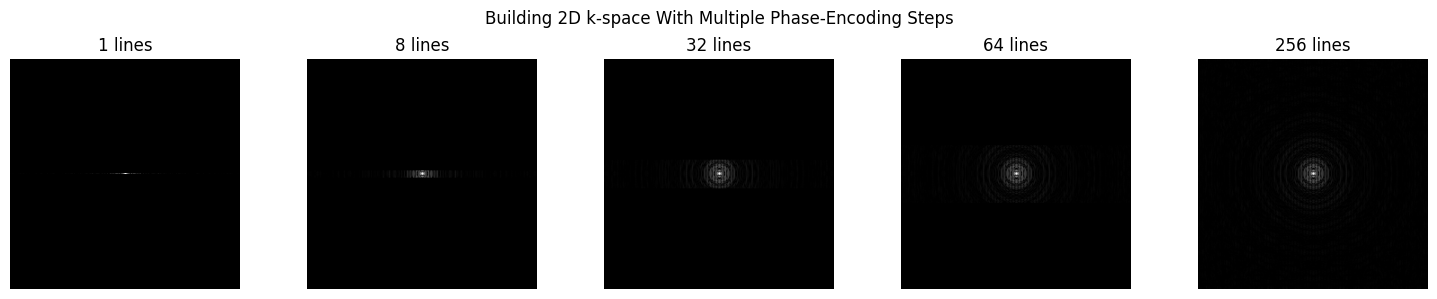

In [73]:
# Number of ky lines to display
line_counts = [
    1,
    8,
    32,
    64,
    N2
]

fig, axes = plt.subplots(
    1,
    len(line_counts),
    figsize=(15, 3)
)

for ax, n_lines in zip(
    axes,
    line_counts
):

    # Empty k-space
    partial_kspace = np.zeros_like(
        kspace_2d
    )

    # Fill a set of lines around the center
    start = (
        N2 // 2
        - n_lines // 2
    )

    end = (
        start
        + n_lines
    )

    partial_kspace[
        start:end,
        :
    ] = kspace_2d[
        start:end,
        :
    ]

    ax.imshow(
        np.log1p(
            np.abs(partial_kspace)
        ),
        cmap="gray",
        origin="lower"
    )

    ax.set_title(
        f"{n_lines} lines"
    )

    ax.axis("off")


plt.suptitle(
    "Building 2D k-space With Multiple Phase-Encoding Steps"
)

plt.tight_layout()
plt.show()

Once all required phase-encoding steps have been acquired, the scanner has collected a complete two-dimensional spatial-frequency dataset:

$$
\boxed{
S(k_x,k_y)
}
$$

We now have exactly the information required for 2D Fourier reconstruction.

## 2.11 Reconstruct the 2D MRI image

We have now reached the same Fourier relationship introduced in Section 1:

$$
\rho(x,y)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x,k_y).
$$

But the direction of the problem has changed.

### In Section 1

We started with a known object:

$$
\rho(x,y)
$$

and calculated:

$$
S(k_x,k_y).
$$

### In MRI

The object is unknown.

The scanner uses gradients and ADC sampling to acquire:

$$
S(k_x,k_y).
$$

Reconstruction then recovers:

$$
\rho(x,y).
$$

Therefore:

$$
\boxed{
S(k_x,k_y)
\xrightarrow{\mathrm{IFFT2}}
\rho(x,y)
}
$$

Let's perform the final reconstruction.

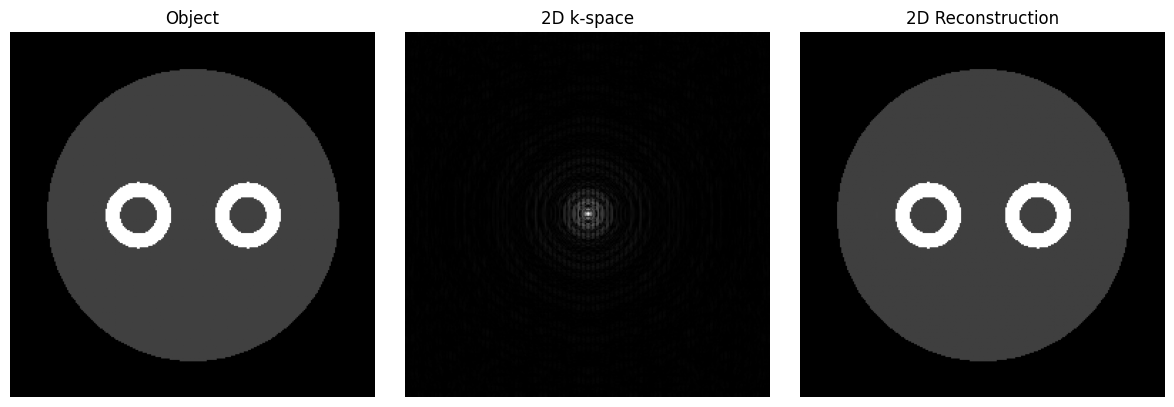

In [74]:
mri_reconstruction = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(
            kspace_2d
        ),
        norm="ortho"
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

# --------------------------------
# Object
# --------------------------------

axes[0].imshow(
    phantom,
    cmap="gray"
)

axes[0].set_title(
    "Object"
)

axes[0].axis("off")


# --------------------------------
# k-space
# --------------------------------

axes[1].imshow(
    np.log1p(
        np.abs(kspace_2d)
    ),
    cmap="gray",
    origin="lower"
)

axes[1].set_title(
    "2D k-space"
)

axes[1].axis("off")


# --------------------------------
# Reconstruction
# --------------------------------

axes[2].imshow(
    np.abs(mri_reconstruction),
    cmap="gray"
)

axes[2].set_title(
    "2D Reconstruction"
)

axes[2].axis("off")


plt.tight_layout()
plt.show()

# Notebook 1 — Milestone Reached

We started with a simple spatial object and ended with a complete 2D MRI reconstruction.

## Step 1 — Spatial information

For one dimension:

$$
\boxed{
\rho(x)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x)
}
$$

For two dimensions:

$$
\boxed{
\rho(x,y)
\;\xleftrightarrow{\mathrm{Fourier}}\;
S(k_x,k_y)
}
$$

---

## Step 2 — A 2D object can produce a 1D projection

$$
P_x(x)
=
\int
\rho(x,y)\,dy.
$$

Therefore:

$$
\boxed{
\text{2D object}
\rightarrow
\text{1D projection}
}
$$

This became the conceptual bridge to MRI.

---

## Step 3 — RF spin echo

Without spatial encoding:

$$
\boxed{
\text{RF spin echo}
\rightarrow
S(t)
}
$$

but we cannot determine where the signal originated.

---

## Step 4 — Frequency encoding

Adding:

$$
G_x
$$

provides spatial encoding along one direction.

The gradient trajectory defines:

$$
k_x(t)
=
\frac{\gamma}{2\pi}
\int
G_x(t)\,dt.
$$

Therefore:

$$
S(t)
\rightarrow
S(k_x).
$$

And:

$$
\boxed{
S(k_x)
\xrightarrow{\mathrm{IFFT}}
P_x(x)
}
$$

One frequency-encoded readout reconstructs a **1D projection**.

---

## Step 5 — Phase encoding

Adding:

$$
G_y
$$

provides spatial-frequency information along a second direction.

Each spin-echo repetition acquires:

$$
S(k_x,k_{y,n}).
$$

Repeating with multiple phase-encoding amplitudes builds:

$$
S(k_x,k_y).
$$

---

## Step 6 — 2D reconstruction

Finally:

$$
\boxed{
S(k_x,k_y)
\xrightarrow{\mathrm{IFFT2}}
\rho(x,y)
}
$$

So the complete progression is:

$$
\boxed{
\begin{array}{c}
\text{RF spin echo}\\
\downarrow\\
S(t)\\
\downarrow\\
+G_x\\
\downarrow\\
S(k_x)\\
\downarrow\\
\text{1D projection}\\
\downarrow\\
+G_y\text{ and repeated readouts}\\
\downarrow\\
S(k_x,k_y)\\
\downarrow\\
\mathrm{IFFT2}\\
\downarrow\\
\text{2D image}
\end{array}
}
$$

## The central idea

> **MRI reconstruction converts spatial-frequency measurements acquired by the scanner into spatial images.**

# Up Next — When k-space is not perfect

So far, we have worked with an ideal MRI experiment:

$$
\boxed{
\text{Complete k-space}
\rightarrow
\mathrm{IFFT2}
\rightarrow
\text{Image}
}
$$

But real MRI reconstruction is rarely this simple.

---

### What happens if we change the data?

| k-space | What happens to the image? |
|---|---|
| Keep only some spatial frequencies | ? |
| Reduce the number of acquired samples | ? |
| Remove k-space lines | ? |
| Add measurement noise | ? |
| Use real scanner data | ? |

---

## Notebook 2 — From Ideal k-space to Real MRI Data

We will explore:

**k-space content** $\rightarrow$ **sampling** $\rightarrow$ **missing data** $\rightarrow$ **noise** $\rightarrow$ **artifacts** $\rightarrow$ **reconstruction**

and finally...

$$
\boxed{
\text{Raw 47 mT phantom data}
\rightarrow
\text{k-space}
\rightarrow
\text{our own reconstructed MRI image}
}
$$

> **If the measured data are imperfect, how does that imperfection appear in the reconstructed image?**